In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping





In [2]:
import kagglehub

dataset_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", dataset_path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [3]:
import os

for root, dirs, files in os.walk(dataset_path):
    print(root)
    if len(files) > 0:
        print("Sample files:", files[:3])
    print("-"*50)

/kaggle/input/chest-xray-pneumonia
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray
Sample files: ['.DS_Store']
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val
Sample files: ['.DS_Store']
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA
Sample files: ['person1947_bacteria_4876.jpeg', 'person1946_bacteria_4875.jpeg', 'person1952_bacteria_4883.jpeg']
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL
Sample files: ['NORMAL2-IM-1431-0001.jpeg', 'NORMAL2-IM-1440-0001.jpeg', 'NORMAL2-IM-1442-0001.jpeg']
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test
Sample files: ['.DS_St

In [4]:
import os

base_path = os.path.join(dataset_path, "chest_xray")

train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")
val_path = os.path.join(base_path, "val")

print(train_path)
print(test_path)
print(val_path)

/kaggle/input/chest-xray-pneumonia/chest_xray/train
/kaggle/input/chest-xray-pneumonia/chest_xray/test
/kaggle/input/chest-xray-pneumonia/chest_xray/val


In [5]:
print("Training")

print("NORMAL:", len(os.listdir(os.path.join(train_path, "NORMAL"))))
print("PNEUMONIA:", len(os.listdir(os.path.join(train_path, "PNEUMONIA"))))

print("\nTesting")

print("NORMAL:", len(os.listdir(os.path.join(test_path, "NORMAL"))))
print("PNEUMONIA:", len(os.listdir(os.path.join(test_path, "PNEUMONIA"))))

print("\nValidation")

print("NORMAL:", len(os.listdir(os.path.join(val_path, "NORMAL"))))
print("PNEUMONIA:", len(os.listdir(os.path.join(val_path, "PNEUMONIA"))))

Training
NORMAL: 1341
PNEUMONIA: 3875

Testing
NORMAL: 234
PNEUMONIA: 390

Validation
NORMAL: 8
PNEUMONIA: 8


In [6]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

validation_generator = test_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


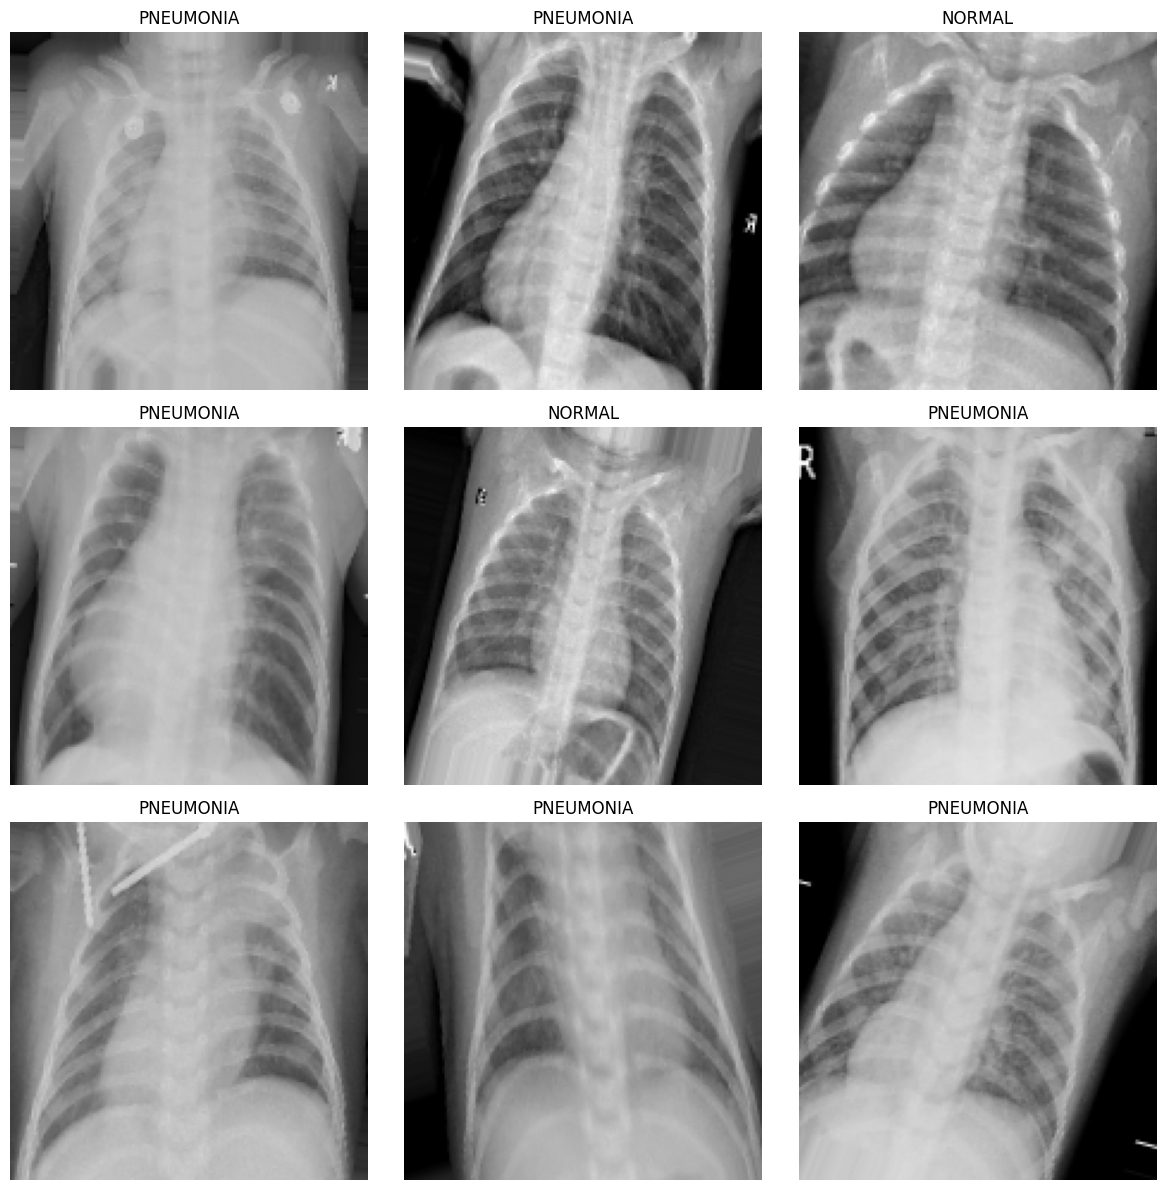

In [7]:
images, labels = next(train_generator)

plt.figure(figsize=(12,12))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title("PNEUMONIA" if labels[i] == 1 else "NORMAL")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,634,881 (13.87 MB)

 Trainable params: 3,633,921 (13.86 MB)

 Non-trainable params: 960 (3.75 KB)

In [10]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 531s 3s/step - accuracy: 0.8436 - loss: 0.7196 - val_accuracy: 0.5000 - val_loss: 27.0190
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 541s 3s/step - accuracy: 0.8842 - loss: 0.3335 - val_accuracy: 0.5000 - val_loss: 59.5456
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 501s 3s/step - accuracy: 0.9080 - loss: 0.2515 - val_accuracy: 0.5000 - val_loss: 18.0706
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 497s 3s/step - accuracy: 0.9099 - loss: 0.2415 - val_accuracy: 0.5000 - val_loss: 8.5161
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 506s 3s/step - accuracy: 0.9156 - loss: 0.2460 - val_accuracy: 0.6250 - val_loss: 0.6013


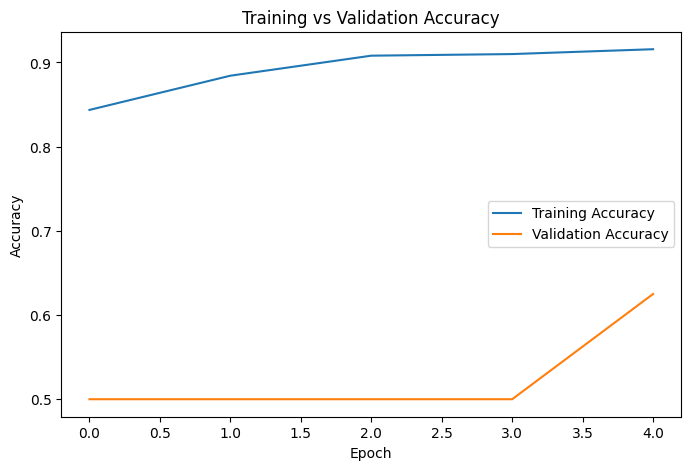

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

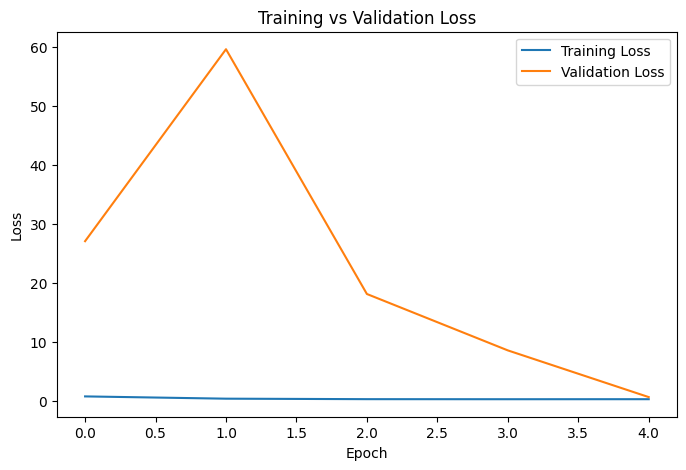

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [13]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 801ms/step - accuracy: 0.7837 - loss: 0.4685
Test Loss: 0.46853744983673096
Test Accuracy: 0.7836538553237915


In [14]:
predictions = model.predict(test_generator)

predicted_classes = (predictions > 0.5).astype(int)

true_classes = test_generator.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 756ms/step


In [15]:
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=["NORMAL","PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.64      0.97      0.77       234
   PNEUMONIA       0.98      0.67      0.79       390

    accuracy                           0.78       624
   macro avg       0.81      0.82      0.78       624
weighted avg       0.85      0.78      0.79       624



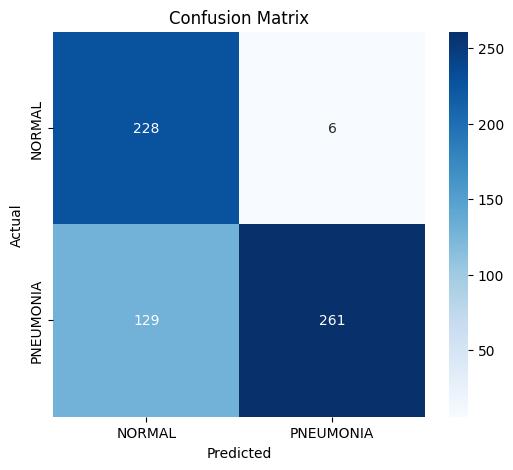

In [16]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["NORMAL","PNEUMONIA"],
    yticklabels=["NORMAL","PNEUMONIA"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
Prediction : NORMAL


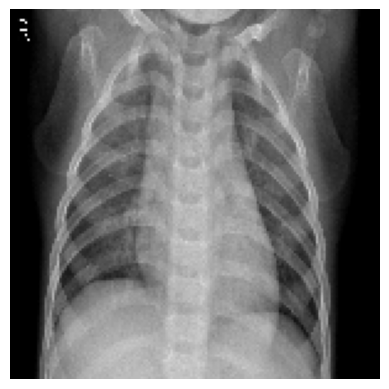

In [19]:
from tensorflow.keras.preprocessing import image
import numpy as np
sample_image = os.path.join(test_path, "NORMAL", os.listdir(os.path.join(test_path, "NORMAL"))[0])

img = image.load_img(sample_image, target_size=(150,150))

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = model.predict(img_array)

plt.imshow(img)
plt.axis("off")

if prediction[0][0] > 0.5:
    print("Prediction : PNEUMONIA")
else:
    print("Prediction : NORMAL")

In [18]:
model.save("Pneumonia_CNN_Model.keras")

print("Model saved successfully!")

Model saved successfully!
